In [19]:
import base64
import time
from io import BytesIO
from pathlib import Path
from typing import Optional

import pypdfium2 as pdfium
from IPython.display import Image
from openai import OpenAI

MODEL_NAME = "ggml-org/gemma-4-26B-A4B-it-GGUF:Q4_K_M"

client = OpenAI(base_url="http://127.0.0.1:8080/", api_key="api-keys-are-for-losers")

In [56]:
def extract_from_file(
    file_path: str | Path, prompt: str, max_pages: Optional[int] = None
) -> str:
    t0_total = time.perf_counter()
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    content = [{"type": "text", "text": prompt}]

    if suffix == ".pdf":
        print(f"[*] Rasterizing '{file_path}' with pypdfium2...")
        t0_pdf = time.perf_counter()

        pdf = pdfium.PdfDocument(str(file_path))
        page_count = len(pdf)
        page_limit = page_count if max_pages is None else min(max_pages, page_count)

        try:
            for page_index in range(page_limit):
                page = pdf.get_page(page_index)
                try:
                    image = page.render(scale=1).to_pil()
                finally:
                    page.close()

                buffered = BytesIO()
                image.save(buffered, format="JPEG", quality=90)
                img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

                content.append(
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"},
                    }
                )
        finally:
            pdf.close()

        t1_pdf = time.perf_counter()
        print(f"    -> PDF conversion took: {t1_pdf - t0_pdf:.2f} seconds.")
        print(f"    -> Prepared {page_limit} page image(s).")
    elif suffix in {".png", ".jpg", ".jpeg"}:
        print(f"[*] Loading image '{file_path}'...")
        t0_img = time.perf_counter()
        mime_type = "image/png" if suffix == ".png" else "image/jpeg"
        img_b64 = base64.b64encode(file_path.read_bytes()).decode("utf-8")
        content.append(
            {
                "type": "image_url",
                "image_url": {"url": f"data:{mime_type};base64,{img_b64}"},
            }
        )
        t1_img = time.perf_counter()
        print(f"    -> Image load took: {t1_img - t0_img:.2f} seconds.")
    else:
        raise ValueError(
            f"Unsupported file type: '{suffix}'. Expected .pdf, .png, .jpg, or .jpeg."
        )

    print("[*] Sending image(s) to local VLM...")
    print(f"    -> Prepared {len(content) - 1} image payload(s).")
    t0_llm = time.perf_counter()
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": content}],
        # max_tokens=4096,
    )
    t1_llm = time.perf_counter()
    print(f"    -> VLM inference took: {t1_llm - t0_llm:.2f} seconds.")
    print(f"    -> Total latency: {t1_llm - t0_total:.2f} seconds.")

    usage = response.usage
    if usage:
        print("\n[*] Token Usage Metadata:")
        print(f"    -> Prompt Tokens:     {usage.prompt_tokens:,}")
        print(f"    -> Completion Tokens: {usage.completion_tokens:,}")
        print(f"    -> Total Tokens:      {usage.total_tokens:,}")
        print(
            f"    -> Speed:             {usage.completion_tokens / (t1_llm - t0_llm):.2f} output tokens/sec"
        )
    # return response
    return response.choices[0].message.content

## Receipts


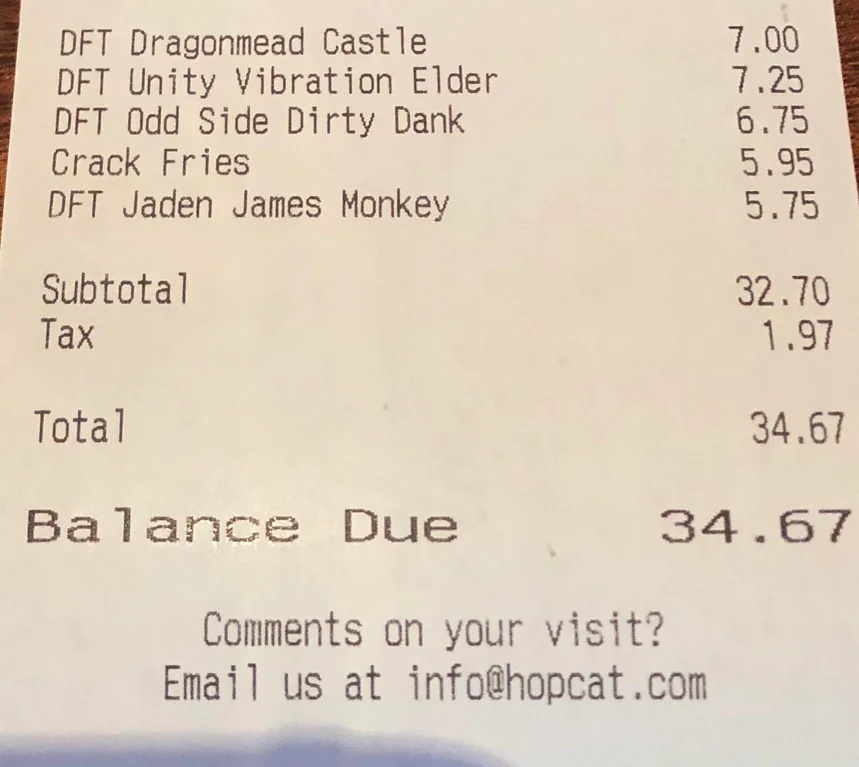

In [22]:
Image(filename="./assets/receipts/naughty.jpg", width=512)

In [30]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

response = extract_from_file(file_path="./assets/receipts/naughty.jpg", prompt=prompt)

[*] Loading image 'assets/receipts/naughty.jpg'...
    -> Image load took: 0.00 seconds.
[*] Sending image(s) to local VLM...
    -> Prepared 1 image payload(s).
    -> VLM inference took: 29.96 seconds.
    -> Total latency: 29.96 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     1,192
    -> Completion Tokens: 1,163
    -> Total Tokens:      2,355
    -> Speed:             38.82 output tokens/sec


In [31]:
print(response)

```json
{
  "line_items": [
    {
      "description": "DFT Dragonmead Castle",
      "price": 7.00
    },
    {
      "description": "DFT Unity Vibration Elder",
      "price": 7.25
    },
    {
      "description": "DFT Odd Side Dirty Dank",
      "price": 6.75
    },
    {
      "description": "Crack Fries",
      "price": 5.95
    },
    {
      "description": "DFT Jaden James Monkey",
      "price": 5.75
    }
  ],
  "total": 34.67,
  "tax": 1.97,
  "merchant": "Hopcat",
  "date": null
}
```


In [37]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

response = extract_from_file(file_path="./assets/receipts/old.jpeg", prompt=prompt)

[*] Loading image 'assets/receipts/old.jpeg'...
    -> Image load took: 0.00 seconds.
[*] Sending image(s) to local VLM...
    -> Prepared 1 image payload(s).
    -> VLM inference took: 91.98 seconds.
    -> Total latency: 91.99 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     1,100
    -> Completion Tokens: 4,096
    -> Total Tokens:      5,196
    -> Speed:             44.53 output tokens/sec


In [38]:
print(response)

## Financial Docs


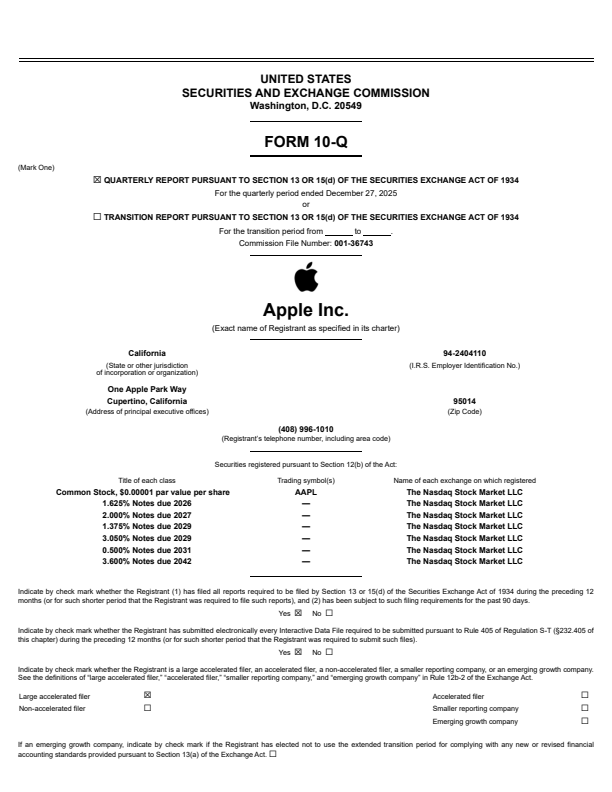

In [39]:
pdf = pdfium.PdfDocument(str("./assets/financial/apple-q1-2026.pdf"))
page = pdf.get_page(0)
image = page.render(scale=1).to_pil()
pdf.close()
image

In [ ]:
prompt = """
Extract the specified data from the financial document. 
Return the company name, form type and company ticker as JSON.
"""

response = extract_from_file(
    file_path="./assets/financial/apple-q1-2026.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.04 seconds.
    -> Prepared 8 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 8 image payload(s).
    -> VLM inference took: 72.35 seconds.
    -> Total latency: 72.39 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     9,414
    -> Completion Tokens: 211
    -> Total Tokens:      9,625
    -> Speed:             2.92 output tokens/sec


In [41]:
print(response)

```json
{
  "company_name": "Apple Inc.",
  "form_type": "FORM 10-Q",
  "company_ticker": "AAPL"
}
```


In [42]:
prompt = """
Extract the specified data from the financial document. 
Return the Note 2 - Revenue table as Markdown.
"""

response = extract_from_file(
    file_path="./assets/financial/apple-q1-2026.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.04 seconds.
    -> Prepared 8 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 8 image payload(s).
    -> VLM inference took: 101.08 seconds.
    -> Total latency: 101.12 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     9,414
    -> Completion Tokens: 1,595
    -> Total Tokens:      11,009
    -> Speed:             15.78 output tokens/sec


In [43]:
print(response)

| | Three Months Ended December 27, 2025 | Three Months Ended December 28, 2024 |
| :--- | :---: | :---: |
| iPhone® | $ 85,269 | $ 69,138 |
| Mac® | 8,386 | 8,987 |
| iPad® | 8,595 | 8,088 |
| Wearables, Home and Accessories | 11,493 | 11,747 |
| Services | 30,013 | 26,340 |
| **Total net sales** | **$ 143,756** | **$ 124,300** |
| | | |
| Portion of total net sales that was included in deferred revenue as of the beginning of the period | $ 4,050 | $ 3,690 |


|                                                                                                    | Three Months Ended December 27, 2025 | Three Months Ended December 28, 2024 |
| :------------------------------------------------------------------------------------------------- | :----------------------------------: | :----------------------------------: |
| iPhone®                                                                                            |               $ 85,269               |               $ 69,138               |
| Mac®                                                                                               |                8,386                 |                8,987                 |
| iPad®                                                                                              |                8,595                 |                8,088                 |
| Wearables, Home and Accessories                                                                    |                11,493                |                11,747                |
| Services                                                                                           |                30,013                |                26,340                |
| **Total net sales**                                                                                |            **$ 143,756**             |            **$ 124,300**             |
|                                                                                                    |                                      |                                      |
| Portion of total net sales that was included in deferred revenue as of the beginning of the period |               $ 4,050                |               $ 3,690                |


In [44]:
prompt = """
Extract the specified data from the financial document. 
Return the condensed consolidated balance sheets table as Markdown.
"""

response = extract_from_file(
    file_path="./assets/financial/nvidia-q3-2025-press-release.pdf", prompt=prompt
)

[*] Rasterizing 'assets/financial/nvidia-q3-2025-press-release.pdf' with pypdfium2...
    -> PDF conversion took: 0.06 seconds.
    -> Prepared 10 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 10 image payload(s).
    -> VLM inference took: 118.91 seconds.
    -> Total latency: 118.97 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     11,657
    -> Completion Tokens: 1,656
    -> Total Tokens:      13,313
    -> Speed:             13.93 output tokens/sec


In [45]:
print(response)

### NVIDIA CORPORATION
### CONDENSED CONSOLIDATED BALANCE SHEETS
**(In millions)**
**(Unaudited)**

| ASSETS | October 26, 2025 | January 26, 2025 |
| :--- | :--- | :--- |
| **Current assets:** | | |
| Cash, cash equivalents and marketable securities | $60,608 | $43,210 |
| Accounts receivable, net | 33,391 | 23,065 |
| Inventories | 19,784 | 10,080 |
| Prepaid expenses and other current assets | 2,709 | 3,771 |
| **Total current assets** | **116,492** | **80,126** |
| Property and equipment, net | 9,780 | 6,283 |
| Operating lease assets | 2,281 | 1,793 |
| Goodwill | 6,261 | 5,188 |
| Intangible assets, net | 936 | 807 |
| Deferred income tax assets | 13,674 | 10,979 |
| Other assets | 11,724 | 6,425 |
| **Total assets** | **$161,148** | **$111,601** |
| | | |
| **LIABILITIES AND SHAREHOLDERS' EQUITY** | | |
| **Current liabilities:** | | |
| Accounts payable | $8,624 | $6,310 |
| Accrued and other current liabilities | 16,452 | 11,737 |
| Short-term debt | 999 | - |
| **Total curren

### NVIDIA CORPORATION

### CONDENSED CONSOLIDATED BALANCE SHEETS

**(In millions)**
**(Unaudited)**

| ASSETS                                           | October 26, 2025 | January 26, 2025 |
| :----------------------------------------------- | :--------------- | :--------------- |
| **Current assets:**                              |                  |                  |
| Cash, cash equivalents and marketable securities | $60,608          | $43,210          |
| Accounts receivable, net                         | 33,391           | 23,065           |
| Inventories                                      | 19,784           | 10,080           |
| Prepaid expenses and other current assets        | 2,709            | 3,771            |
| **Total current assets**                         | **116,492**      | **80,126**       |
| Property and equipment, net                      | 9,780            | 6,283            |
| Operating lease assets                           | 2,281            | 1,793            |
| Goodwill                                         | 6,261            | 5,188            |
| Intangible assets, net                           | 936              | 807              |
| Deferred income tax assets                       | 13,674           | 10,979           |
| Other assets                                     | 11,724           | 6,425            |
| **Total assets**                                 | **$161,148**     | **$111,601**     |
|                                                  |                  |                  |
| **LIABILITIES AND SHAREHOLDERS' EQUITY**         |                  |                  |
| **Current liabilities:**                         |                  |                  |
| Accounts payable                                 | $8,624           | $6,310           |
| Accrued and other current liabilities            | 16,452           | 11,737           |
| Short-term debt                                  | 999              | -                |
| **Total current liabilities**                    | **26,075**       | **18,047**       |
| Long-term debt                                   | 7,468            | 8,463            |
| Long-term operating lease liabilities            | 2,014            | 1,519            |
| Other long-term liabilities                      | 6,694            | 4,245            |
| **Total liabilities**                            | **42,251**       | **32,274**       |
| Shareholders' equity                             | 118,897          | 79,327           |
| **Total liabilities and shareholders' equity**   | **$161,148**     | **$111,601**     |


In [57]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
response = extract_from_file(
    file_path="./assets/papers/simple-self-distillation-excerpt.pdf", prompt=prompt
)

[*] Rasterizing 'assets/papers/simple-self-distillation-excerpt.pdf' with pypdfium2...
    -> PDF conversion took: 0.22 seconds.
    -> Prepared 8 page image(s).
[*] Sending image(s) to local VLM...
    -> Prepared 8 image payload(s).
    -> VLM inference took: 108.90 seconds.
    -> Total latency: 109.12 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     9,430
    -> Completion Tokens: 5,318
    -> Total Tokens:      14,748
    -> Speed:             48.83 output tokens/sec


In [58]:
print(response)

Based on the SSD temperature sweep heatmap in **Figure 3(b)**, which displays the `pass@1` results for Qwen3-4B-Thinking across different $T_{train}$ (y-axis) and $T_{eval}$ (x-axis) configurations, the value at $T_{eval} = 1.2$ and $T_{train} = 0.9$ is **55.3**.


Based on the SSD temperature sweep heatmap in **Figure 3(b)**, which displays the `pass@1` results for Qwen3-4B-Thinking across different $T_{train}$ (y-axis) and $T_{eval}$ (x-axis) configurations, the value at $T_{eval} = 1.2$ and $T_{train} = 0.9$ is **55.3**.


In [59]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
response = extract_from_file(file_path="./assets/papers/single-page.jpg", prompt=prompt)

[*] Loading image 'assets/papers/single-page.jpg'...
    -> Image load took: 0.00 seconds.
[*] Sending image(s) to local VLM...
    -> Prepared 1 image payload(s).
    -> VLM inference took: 77.92 seconds.
    -> Total latency: 77.92 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     1,226
    -> Completion Tokens: 3,584
    -> Total Tokens:      4,810
    -> Speed:             45.99 output tokens/sec


In [60]:
print(response)

Based on the SSD temperature sweep table (Figure 3b), the value at $T_{\text{eval}} = 1.2$ and $T_{\text{train}} = 0.9$ is **51.7**.


Based on the SSD temperature sweep table (Figure 3b), the value at $T_{\text{eval}} = 1.2$ and $T_{\text{train}} = 0.9$ is **51.7**.
